In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast
import torch
from transformers import BertForMaskedLM, DataCollatorForLanguageModeling
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
from transformers import DataCollatorForLanguageModeling
from sklearn.model_selection import train_test_split
import os
import torch.nn as nn
import torch.nn.functional as F

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jupyter/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-11-25 12:46:59.440326: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `

In [2]:
import lightning as L
import random
def set_random_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


set_random_seed(42)
L.seed_everything(42)

Seed set to 42


42

In [38]:
path_dir_models = '/home/jupyter/datasphere/project/CNN/CNN Models/'

model_n_to_save = '16'

epochs = 100
learning_rate = 5e-4


for dir in ['transfer learning plots','after learning plots']:
  dir_to_create_path = path_dir_models + model_n_to_save + '/' + dir
  os.makedirs(dir_to_create_path, exist_ok=True)

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

def plot_r2_function(y_true, preds, dir_to_save=None):
    r2 = r2_score(y_true, preds)
    fig = plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=preds, alpha=0.6)
    plt.plot([min(y_true), max(y_true)],
             [min(y_true), max(y_true)],
             color='red', linestyle='--', linewidth=1)
    plt.title(f"Scatter plot: True vs Predicted values\n$R^2$ = {r2:.3f}", fontsize=14)
    plt.xlabel("True values", fontsize=12)
    plt.ylabel("Predicted values", fontsize=12)
    plt.grid(True, alpha=0.3)
    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    return {"rmse": np.sqrt(mean_squared_error(labels, predictions))}

def plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=None):
    sns.set_style("ticks")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    xlabel = "Values"
    ylabel = "Counts"

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.6, ax=axes[0])
    axes[0].set_title("Distribution Predicted values", fontsize=14)
    axes[0].set_xlabel(xlabel, fontsize=12)
    axes[0].set_ylabel(ylabel, fontsize=12)
    axes[0].legend(fontsize=12)

    sns.histplot(preds, kde=True, color="blue", label=preds_label, alpha=0.5, ax=axes[1])
    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.5,  ax=axes[1])
    axes[1].set_title("True vs Predicted values distribution", fontsize=14)
    axes[1].set_xlabel(xlabel, fontsize=12)
    axes[1].set_ylabel(ylabel, fontsize=12)
    axes[1].legend(fontsize=12)

    sns.histplot(y_true, kde=True, color="red", label=true_label, alpha=0.6, ax=axes[2])
    axes[2].set_title("Distribution True values", fontsize=14)
    axes[2].set_xlabel(xlabel, fontsize=12)
    axes[2].set_ylabel(ylabel, fontsize=12)
    axes[2].legend(fontsize=12)

    plt.tight_layout()

    if dir_to_save is not None:
        plt.savefig(dir_to_save, dpi=300, bbox_inches='tight')
    plt.show()

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):  
    def __init__(self, embedding_dim=128):
        super(ConvNet, self).__init__()  

        weights = torch.tensor([
            [1.0, 0.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0]
        ])
        
        
        self.emb_layer1 = nn.Embedding.from_pretrained(weights, freeze=True, padding_idx=0)
        self.emb_layer2 = nn.Embedding(
            num_embeddings=620,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        
        
        self.conv_stack1 = nn.Sequential(
            nn.Conv1d(in_channels=5, out_channels=50, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=50, out_channels=150, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=150, out_channels=250, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=250, out_channels=150, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.AdaptiveAvgPool1d(output_size=1)
        )
        
        self.conv_stack2 = nn.Sequential(
            nn.Conv1d(in_channels=embedding_dim, out_channels=30, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=30, out_channels=70, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=70, out_channels=100, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=100, out_channels=60, kernel_size=3, padding=1),    
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.adds_stack = nn.Sequential(
            nn.Linear(in_features=3, out_features=50),
            nn.ReLU(),
            
            nn.Linear(in_features=50, out_features=20),
            nn.ReLU(),
        )
            
        self.mlp = nn.Sequential(
            nn.Linear(in_features=230, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1),
        )
        
        self.avg_pool = nn.AdaptiveAvgPool1d(output_size=1)

    def forward(self, x1, adds, cres):
        x1 = self.emb_layer1(x1)      
        x1 = x1.transpose(1, 2)
        x1 = self.conv_stack1(x1)
        x1 = self.avg_pool(x1)
        x1 = x1.flatten(1)
        
        adds = self.adds_stack(adds)
        
        cres = self.emb_layer2(cres)      
        cres = cres.transpose(1, 2)
        cres = self.conv_stack2(cres)
        cres = self.avg_pool(cres)
        cres = cres.flatten(1)
        
        res = torch.cat([x1, adds, cres], dim=1)
        output = self.mlp(res)
        return output

In [44]:
# Тестирование
cnn_model = ConvNet()

'''# Пример прямого прохода
input_tensor1 = torch.randint(0, 5, (32, 100))
input_tensor2 = torch.randint(0, 5, (32, 3)) # (batch, seq_len)
output = cnn_model(input_tensor1, input_tensor2)
print(f"Output shape: {output.shape}")  # Должно быть: torch.Size([32, 1])'''
cnn_model

ConvNet(
  (emb_layer1): Embedding(5, 5, padding_idx=0)
  (emb_layer2): Embedding(620, 128, padding_idx=0)
  (conv_stack1): Sequential(
    (0): Conv1d(5, 50, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(50, 150, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(150, 250, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(250, 150, kernel_size=(3,), stride=(1,), padding=(1,))
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool1d(output_size=1)
  )
  (conv_stack2): Sequential(
    (0): Conv1d(128, 30, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(k

In [45]:
from torch.optim import AdamW
from transformers import BertForMaskedLM, get_cosine_schedule_with_warmup
from torchmetrics import MeanMetric, Accuracy
import math
from torchmetrics import MetricCollection
from torchmetrics.regression import (
    MeanSquaredError,
    MeanAbsoluteError,
    R2Score,
    ExplainedVariance,
    PearsonCorrCoef,
    SpearmanCorrCoef,
    MeanSquaredLogError,
    CosineSimilarity
)


class Pipeline(L.LightningModule):
    def __init__(
        self,
        model,
        exp_name="baseline",
        criterion=nn.MSELoss(),
        optimizer_class=torch.optim.AdamW,
        optimizer_kwargs={"lr": 1e-4, "weight_decay": 0.01},
        warmup_steps=1000,
        total_steps=None,
        path_plot_save=None
    ) -> None:
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.total_steps = total_steps
        self.optimizer_class = optimizer_class
        self.optimizer_kwargs = optimizer_kwargs
        self.warmup_steps = warmup_steps
        self.path_plot_save = path_plot_save
        metrics = MetricCollection({
            'mse': MeanSquaredError(),
            'rmse': MeanSquaredError(squared=False),  # RMSE
            'mae': MeanAbsoluteError(),
            'r2': R2Score(),
            'explained_variance': ExplainedVariance(),
            'pearson': PearsonCorrCoef(),
            'spearman': SpearmanCorrCoef(),
        })
        self.train_metrics = metrics.clone(postfix="/train")
        self.valid_metrics = metrics.clone(postfix="/val")
        self.test_metrics = metrics.clone(postfix="/test")
        
        self.save_hyperparameters(ignore=['model', 'criterion'])
        self.test_true_values = []
        self.test_preds = []


    def configure_optimizers(self):
            optimizer = self.optimizer_class(
                self.model.parameters(), **self.optimizer_kwargs
            )

            # Если total_steps не задан, вычисляем автоматически
            if self.total_steps is None and self.trainer is not None:
                self.total_steps = self.trainer.estimated_stepping_batches

            if self.total_steps:
                scheduler = get_cosine_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps=self.warmup_steps,
                    num_training_steps=self.total_steps,
                    num_cycles=0.5  # Для cosine annealing
                )

                return {
                    "optimizer": optimizer,
                    "lr_scheduler": {
                        "scheduler": scheduler,
                        "interval": "step",
                        "frequency": 1,
                    },
                }
            else:
                return optimizer

    def training_step(self, batch, batch_idx):
        x1, adds, cres, labels = batch
        out = self.model(x1, adds, cres)
        loss = self.criterion(out.squeeze(), labels)
        self.log("Loss/train", loss, prog_bar=True)
        self.train_metrics.update(out.squeeze(), labels)
        if self.trainer and self.trainer.optimizers:
                self.log('learning_rate', self.trainer.optimizers[0].param_groups[0]['lr'], on_step=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x1, adds, cres, labels = batch
        out = self.model(x1, adds, cres)
        loss = self.criterion(out.squeeze(), labels)
        self.log("Loss/val", loss, prog_bar=True)
        self.valid_metrics.update(out.squeeze(), labels)
        #print("\nПримеры предсказаний:")
        #for i in range(5):
            #print(f"True: {labels[i].item():.3f} | Pred: {out.squeeze()[i].item():.3f}")

    def test_step(self, batch, batch_idx):
        x1, adds, cres, labels = batch
        out = self.model(x1, adds, cres)
        self.test_metrics.update(out.squeeze(), labels)
        self.test_true_values.extend(labels)
        self.test_preds.extend(out.squeeze())

    def on_training_epoch_end(self):
        train_metrics = self.train_metrics.compute()
        self.log("train_r2", train_metrics['r2/train'], prog_bar=True)
        self.log("train_rmse", train_metrics['rmse/train'], prog_bar=True)
        self.log_dict(train_metrics)
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        valid_metrics = self.valid_metrics.compute()
        self.log("val_r2", valid_metrics['r2/val'], prog_bar=True)
        self.log("val_rmse", valid_metrics['rmse/val'], prog_bar=True)
        self.log_dict(valid_metrics)
        self.valid_metrics.reset()

    def on_test_epoch_end(self):
        test_metrics = self.test_metrics.compute()
        self.log_dict(test_metrics, sync_dist=True)
        self.test_metrics.reset()
        y_true = torch.tensor(self.test_true_values).cpu().numpy()
        preds = torch.tensor(self.test_preds).cpu().numpy()
        plot_r2_function(y_true, preds, dir_to_save=self.path_plot_save)
        plot_preds_vs_true_histplots(preds, y_true, preds_label="Predictions", true_label="True values", dir_to_save=self.path_plot_save)
        
        
        self._log_metrics_analysis(test_metrics, "test")

    def _log_metrics_analysis(self, metrics, stage):
        """Анализ и логирование метрик"""
        analysis_text = f"""
        {stage.upper()} METRICS ANALYSIS:
        • R²: {metrics[f'r2/{stage}']:.4f} (ближе к 1.0 = лучше)
        • RMSE: {metrics[f'rmse/{stage}']:.4f} (в тех же единицах что и target)
        • MAE: {metrics[f'mae/{stage}']:.4f} (средняя абсолютная ошибка)
        • Pearson: {metrics[f'pearson/{stage}']:.4f} (линейная корреляция)
        • Spearman: {metrics[f'spearman/{stage}']:.4f} (ранговая корреляция)
        """
        
        # Логируем в TensorBoard
        self.logger.experiment.add_text(
            f"{stage}_metrics_analysis/epoch_{self.current_epoch}",
            f"```\n{analysis_text}\n```",
            self.current_epoch
        )

In [46]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger



exp_name = f'{model_n_to_save}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)

pipeline = Pipeline(
    model=cnn_model,
    exp_name=exp_name,
    optimizer_class=AdamW,
    optimizer_kwargs={"lr": learning_rate, "weight_decay": 0.1},
    warmup_steps=1000,
    path_plot_save=path_dir_models + model_n_to_save + '/'
)

checkpoint_callback = ModelCheckpoint(
    monitor="Loss/val", mode="min", filename="best"
)

trainer = Trainer(
        max_epochs=epochs,
        callbacks=[checkpoint_callback],
        log_every_n_steps=100,
        logger=logger,
    )

trainer.fit(
    model=pipeline,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | ConvNet          | 388 K  | train
1 | criterion     | MSELoss          | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | valid_metrics | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
388 K     Trainable params
25        Non-trainable params

Epoch 0: 100%|██████████| 232/232 [00:05<00:00, 40.10it/s, v_num=1, Loss/train=1.050]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 232/232 [00:05<00:00, 40.60it/s, v_num=1, Loss/train=0.858, Loss/val=0.775, val_r2=0.000938, val_rmse=0.880]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 232/232 [00:05<00:00, 40.41it/s, v_num=1, Loss/train=0.807, Loss/val=0.764, val_r2=0.0142, val_rmse=0.874]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 232/232 [00:05<00:00, 40.43it/s, v_num=1, Loss/train=0.761, Loss/val=0.756, val_r2=0.025, val_rmse=0.869] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 232/232 [00:05<00:00, 40.08it/s, v_num=1, Loss/train=0.518, Loss/val=0.743, val_r2=0.0411, val_rmse=0.862]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 232/232 [00:05<00:00, 40.27it/s, v_num=1, Loss/train=0.606, Loss/val=0.741, val_r2=0.0439, val_rmse=0.861]
Validation: |  


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 50/50 [00:00<00:00, 70.42it/s]

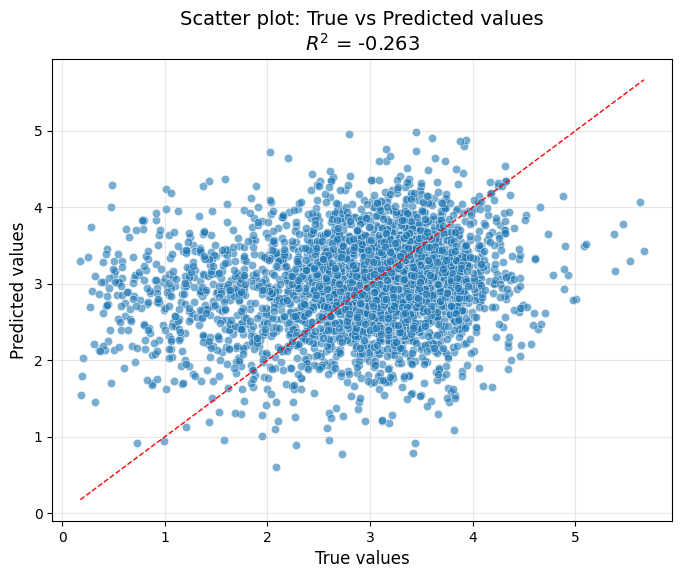

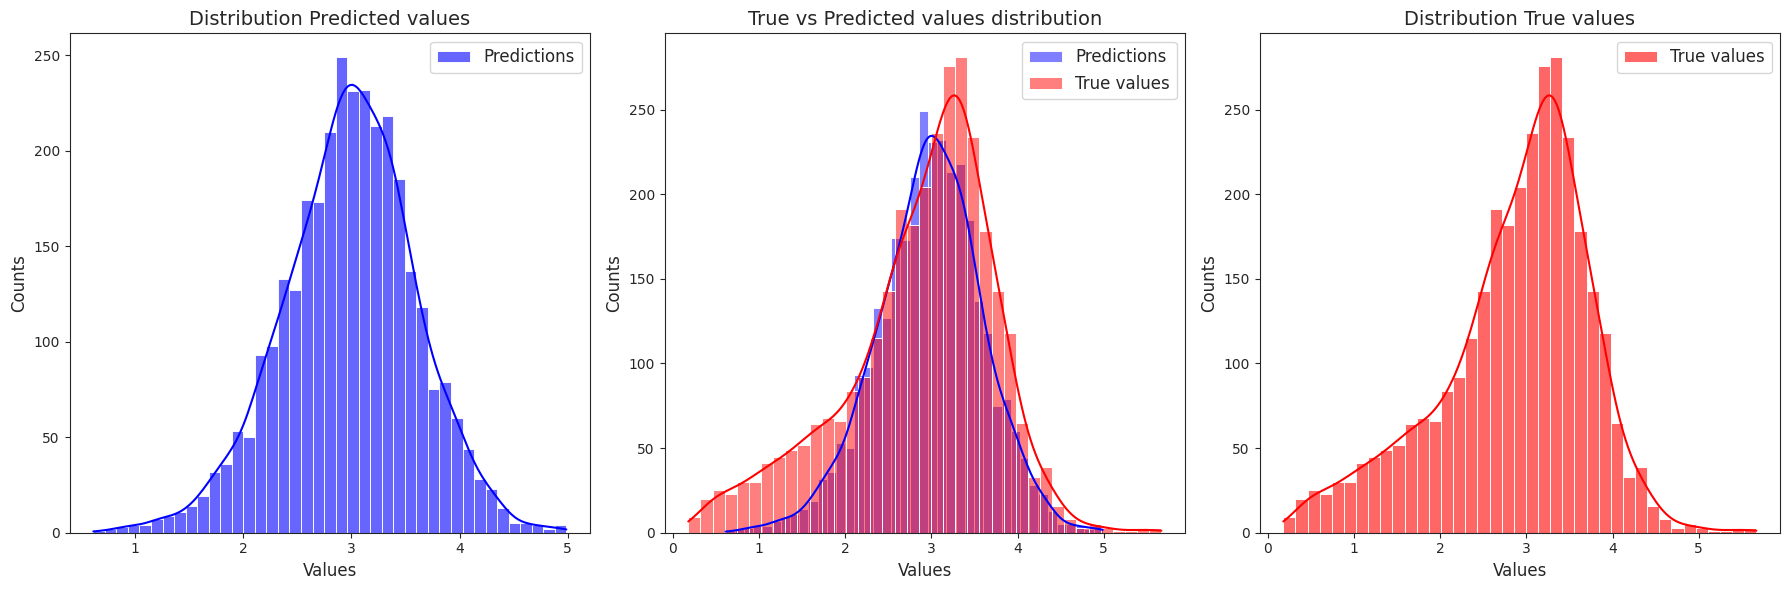

Testing DataLoader 0: 100%|██████████| 50/50 [00:03<00:00, 13.51it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  explained_variance/test  │   -0.24475717544555664    │
│         mae/test          │    0.7592877745628357     │
│         mse/test          │    0.9663658142089844     │
│       pearson/test        │    0.17705632746219635    │
│          r2/test          │   -0.26327311992645264    │
│         rmse/test         │    0.9830390810966492     │
│       spearman/test       │    0.17261749505996704    │
└───────────────────────────┴───────────────────────────┘

[{'explained_variance/test': -0.24475717544555664,
  'mae/test': 0.7592877745628357,
  'mse/test': 0.9663658142089844,
  'pearson/test': 0.17705632746219635,
  'r2/test': -0.26327311992645264,
  'rmse/test': 0.9830390810966492,
  'spearman/test': 0.17261749505996704}]

In [35]:
trainer.test(
    model=pipeline,
    dataloaders=test_loader,
)

In [40]:
checkpoint_path = '/home/jupyter/datasphere/project/CNN/CNN Models/16/logs/16/version_0/checkpoints/best.ckpt'

In [41]:
pipeline = Pipeline.load_from_checkpoint(checkpoint_path, model=ConvNet())

/home/jupyter/.local/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 50/50 [00:00<00:00, 98.84it/s] 

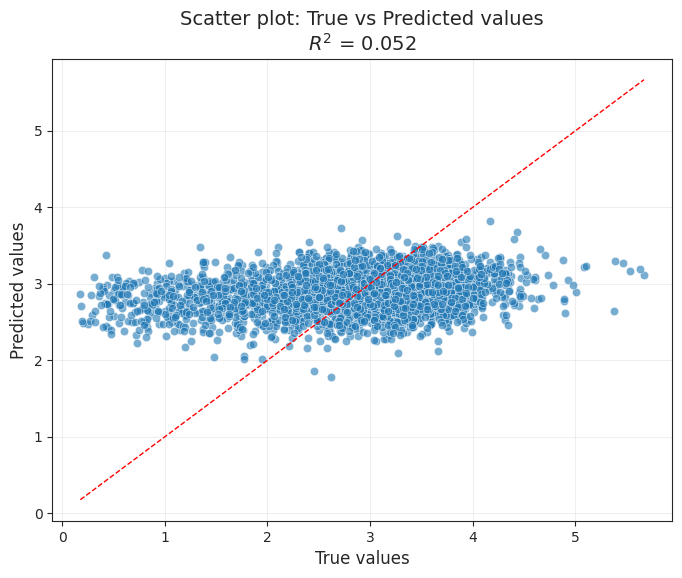

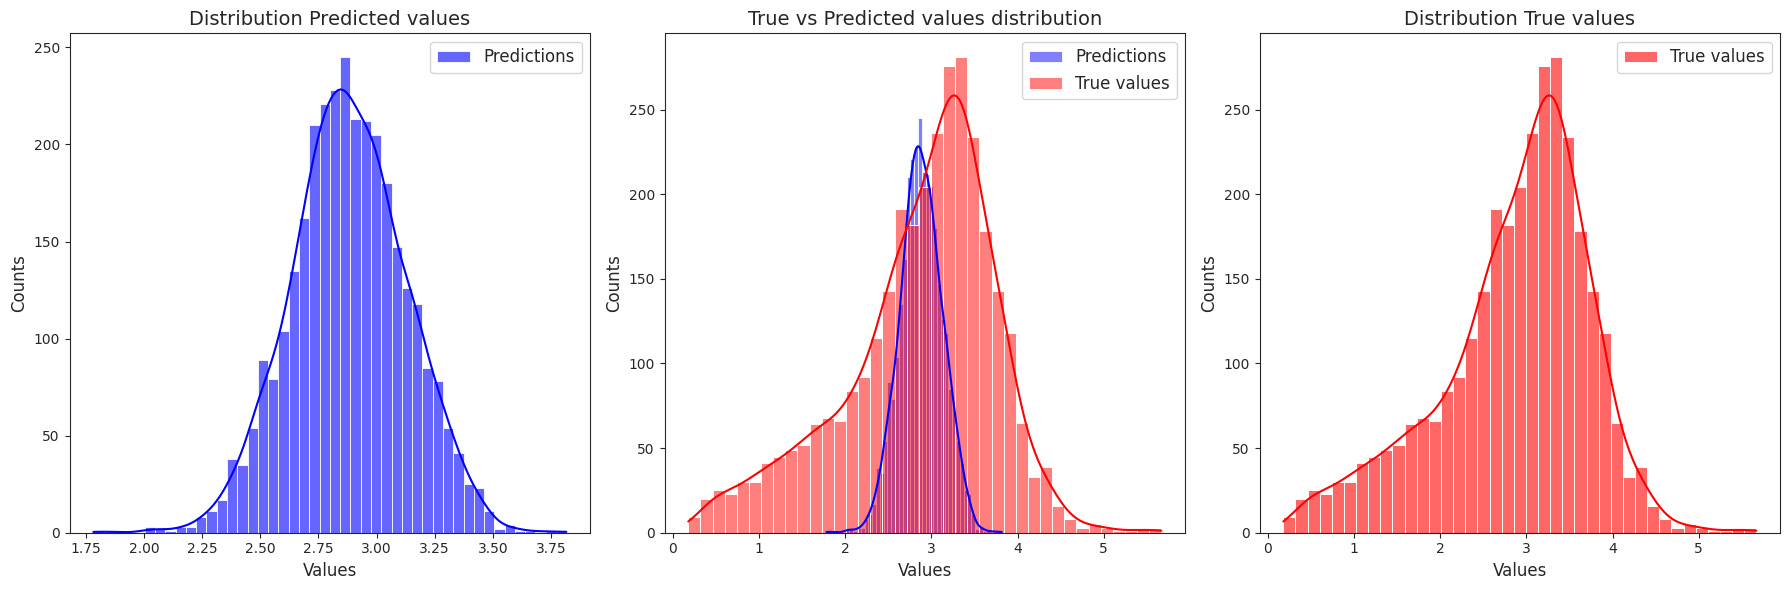

Testing DataLoader 0: 100%|██████████| 50/50 [00:03<00:00, 13.90it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  explained_variance/test  │   0.052955687046051025    │
│         mae/test          │    0.6677352786064148     │
│         mse/test          │    0.7248652577400208     │
│       pearson/test        │    0.2349424660205841     │
│          r2/test          │    0.05242639780044556    │
│         rmse/test         │    0.8513901829719543     │
│       spearman/test       │     0.217919260263443     │
└───────────────────────────┴───────────────────────────┘

[{'explained_variance/test': 0.052955687046051025,
  'mae/test': 0.6677352786064148,
  'mse/test': 0.7248652577400208,
  'pearson/test': 0.2349424660205841,
  'r2/test': 0.05242639780044556,
  'rmse/test': 0.8513901829719543,
  'spearman/test': 0.217919260263443}]

In [42]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger

tokenizer = fast_tokenizer

exp_name = f'{model_n_to_save + "finetuned"}'
logger = TensorBoardLogger(save_dir=path_dir_models + model_n_to_save + '/logs/', name=exp_name)


checkpoint_callback = ModelCheckpoint(
    monitor="Loss/val", mode="min", filename="best"
)

trainer = Trainer(
        max_epochs=epochs,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
        logger=logger,
    )

trainer.test(
    model=pipeline,
    dataloaders=test_loader,
)

Датасет

In [10]:
path = '/home/jupyter/datasphere/project/CNN/PRIME_Dataset_plus-minus.csv'
data = pd.read_csv(path)

In [11]:
data['log_mean'] = data['log_mean'] - data['log_mean'].min()

In [12]:
data

,gene_id,mean,log_mean,sequence,-,+
0,AT1G01010,244.885832,2.776282,ACATTTCAAACCACTTGTTCTCTTTTATGTTTTGGTAAGAGCTATC...,"['AT3G22760', 'AT1G35460', 'AT1G51700', 'AT1G2...","['AT1G51140', 'AT2G42280', 'AT4G38620', 'AT1G2..."
1,AT1G01020,367.643741,2.952745,ATCGGATATGACATAGCGGATTTTGTATATCTTTAGAGAGTATGAG...,"['AT3G57920', 'AT4G18960', 'AT1G13450', 'AT1G1...","['AT3G61120', 'AT2G45650', 'AT2G38090', 'AT3G1..."
2,AT1G01030,116.788171,2.454717,TATATAATTTTGATTGAAATTGATGTATACAGCGCAGATGATTTTT...,"['AT4G35550', 'AT1G49480', 'AT1G49480', 'AT3G5...","['AT4G30080', 'AT4G38000', 'AT4G01280', 'AT4G3..."
3,AT1G01040,2077.279230,3.704813,GTGAGGTCCATGTCCACAATAAGAAATCAAATACCAAACAAAGTAT...,"['AT5G13790', 'AT4G18960', 'AT3G57230', 'AT1G7...","['AT5G10140', 'AT5G15800', 'AT3G54340', 'AT1G2..."
4,AT1G01050,1543.546080,3.575838,CTTGTGGACCGCTCATCCTGTGGCTCAAATACACCTTCAGGGAGTG...,"['AT3G46070', 'AT1G51600', 'AT1G69570', 'AT5G4...","['AT2G38090', 'AT2G38090', 'AT4G38910', 'AT2G0..."
...,...,...,...,...,...,...
21180,AT5G67590,1907.232462,3.667722,ATCTTATCCAAACTACAAAAACAGACAATAGCGCAAGATCAAATCT...,"['AT1G70000', 'AT1G74840', 'AT5G08520', 'AT5G0...","['AT1G24260', 'AT2G02080', 'AT1G55110', 'AT2G0..."
21181,AT5G67600,981.665750,3.379282,CAACAAACCAAACTATGTTTGATTATACAGCATCCATATCCCTGAA...,"['AT3G30210', 'AT1G02065', 'AT4G14770', 'AT1G4...","['AT1G13450', 'AT3G24120', 'AT4G11660', 'AT4G1..."
21182,AT5G67610,512.790922,3.097258,GATCCTTAATTTTAGTTCTAGTTGTGACATGATGAATAAGATATTT...,"['AT3G25990', 'AT1G18330', 'AT5G17300', 'AT3G1...","['AT1G32510', 'AT5G18090', 'AT2G38090', 'AT5G0..."
21183,AT5G67620,44.770289,2.038308,TGATATGTATGATTAGGATGTTGAACTCGGATTTATGTTTTTTTTT...,"['AT2G22430', 'AT4G37790', 'AT3G21175', 'AT3G2...","['AT2G18350', 'AT1G69180', 'AT3G24050', 'AT5G5..."


In [13]:
from collections import Counter
import math
def sequence_counter(str_list_cres):
    return math.log10(len(eval(str_list_cres)))

def sequence_entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    entropy = -sum((count/total) * math.log2(count/total) for count in counts.values())
    return entropy

def gc_content(sequence):
    gc_count = sequence.count('G') + sequence.count('C')
    return math.log10(gc_count / len(sequence) * 100)

In [14]:
data['+_len'] = data['+'].map(sequence_counter)
data['GC_cont'] = data['sequence'].map(gc_content)
data['sequence_entropy'] = data['sequence'].map(sequence_entropy)
data.dropna(inplace=True)

In [15]:
def list_short_and_leftpad(sequence):
    l = ['SEP'] * 200
    temp = l + eval(sequence)
    return temp[-100:]

data['pad_+'] = data['+'].map(list_short_and_leftpad)

In [16]:
data

,gene_id,mean,log_mean,sequence,-,+,+_len,GC_cont,sequence_entropy,pad_+
0,AT1G01010,244.885832,2.776282,ACATTTCAAACCACTTGTTCTCTTTTATGTTTTGGTAAGAGCTATC...,"['AT3G22760', 'AT1G35460', 'AT1G51700', 'AT1G2...","['AT1G51140', 'AT2G42280', 'AT4G38620', 'AT1G2...",2.271842,1.499171,1.896286,"[AT1G79180, AT4G28110, AT5G54230, AT5G62320, A..."
1,AT1G01020,367.643741,2.952745,ATCGGATATGACATAGCGGATTTTGTATATCTTTAGAGAGTATGAG...,"['AT3G57920', 'AT4G18960', 'AT1G13450', 'AT1G1...","['AT3G61120', 'AT2G45650', 'AT2G38090', 'AT3G1...",2.320146,1.482516,1.877886,"[AT4G30080, AT3G12820, AT4G38620, AT3G61250, A..."
2,AT1G01030,116.788171,2.454717,TATATAATTTTGATTGAAATTGATGTATACAGCGCAGATGATTTTT...,"['AT4G35550', 'AT1G49480', 'AT1G49480', 'AT3G5...","['AT4G30080', 'AT4G38000', 'AT4G01280', 'AT4G3...",2.352183,1.467978,1.870136,"[AT5G52170, AT3G26790, AT1G28300, AT3G24650, A..."
3,AT1G01040,2077.279230,3.704813,GTGAGGTCCATGTCCACAATAAGAAATCAAATACCAAACAAAGTAT...,"['AT5G13790', 'AT4G18960', 'AT3G57230', 'AT1G7...","['AT5G10140', 'AT5G15800', 'AT3G54340', 'AT1G2...",2.271842,1.495718,1.893342,"[AT1G29160, AT5G62940, AT1G64620, AT3G47500, A..."
4,AT1G01050,1543.546080,3.575838,CTTGTGGACCGCTCATCCTGTGGCTCAAATACACCTTCAGGGAGTG...,"['AT3G46070', 'AT1G51600', 'AT1G69570', 'AT5G4...","['AT2G38090', 'AT2G38090', 'AT4G38910', 'AT2G0...",2.093422,1.557056,1.941922,"[AT1G20640, AT2G01940, AT1G76880, AT1G68670, A..."
...,...,...,...,...,...,...,...,...,...,...
21180,AT5G67590,1907.232462,3.667722,ATCTTATCCAAACTACAAAAACAGACAATAGCGCAAGATCAAATCT...,"['AT1G70000', 'AT1G74840', 'AT5G08520', 'AT5G0...","['AT1G24260', 'AT2G02080', 'AT1G55110', 'AT2G0...",2.155336,1.566732,1.938904,"[AT3G22170, AT3G28910, AT5G39660, AT4G21080, A..."
21181,AT5G67600,981.665750,3.379282,CAACAAACCAAACTATGTTTGATTATACAGCATCCATATCCCTGAA...,"['AT3G30210', 'AT1G02065', 'AT4G14770', 'AT1G4...","['AT1G13450', 'AT3G24120', 'AT4G11660', 'AT4G1...",2.260071,1.523421,1.916002,"[AT2G02070, AT2G40260, AT3G22780, AT4G29000, A..."
21182,AT5G67610,512.790922,3.097258,GATCCTTAATTTTAGTTCTAGTTGTGACATGATGAATAAGATATTT...,"['AT3G25990', 'AT1G18330', 'AT5G17300', 'AT3G1...","['AT1G32510', 'AT5G18090', 'AT2G38090', 'AT5G0...",2.318063,1.542514,1.931508,"[AT4G37180, AT1G52150, AT1G29160, AT3G47500, A..."
21183,AT5G67620,44.770289,2.038308,TGATATGTATGATTAGGATGTTGAACTCGGATTTATGTTTTTTTTT...,"['AT2G22430', 'AT4G37790', 'AT3G21175', 'AT3G2...","['AT2G18350', 'AT1G69180', 'AT3G24050', 'AT5G5...",2.346353,1.470741,1.874789,"[AT5G60130, AT5G17430, AT2G01570, AT5G02460, A..."


In [17]:
x_train, x, y_train, y = train_test_split(data[['sequence', 'pad_+', '+_len', 'GC_cont', 'sequence_entropy']], data['log_mean'],
                                          train_size=0.7, shuffle=True,
                                          random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x, y,
                                                train_size=0.5, shuffle=True,
                                                random_state=42)

<Axes: xlabel='log_mean', ylabel='Count'>

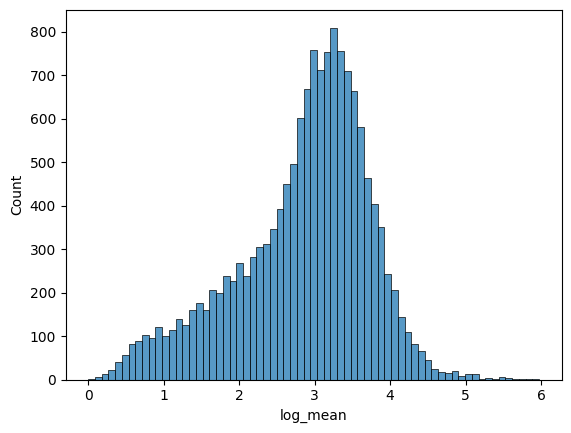

In [18]:
sns.histplot(y_train)

In [19]:
path = '/home/jupyter/datasphere/project/BERT project/' 
fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=path + "my_tokenizer.json",
    pad_token="[PAD]",
    unk_token="[UNK]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

In [20]:
dict_atgc = {'A': 1, 'T': 2, 'G': 3, 'C': 4, 'N': 0}
def dict_atgc_token(seq, dict_atgc):
    result = [dict_atgc[i] for i in seq]
    return result

def to_train_in(df):
    tokenized = [torch.tensor(dict_atgc_token(text, dict_atgc)) 
                 for text in df['sequence'].tolist()]
    adds_ = list(zip(df['+_len'], df['GC_cont'], df['sequence_entropy']))
    adds = [torch.tensor(x) for x in adds_]
    cres = [torch.tensor(fast_tokenizer.encode(' '.join(text))) for text in df['pad_+'].tolist()]
    return tokenized, adds, cres

train_in_plus = to_train_in(x_train)
val_in_plus = to_train_in(x_val)
test_in_plus = to_train_in(x_test)

In [21]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):
    word_ids, y = list(zip(*batch))
    padded_ids = pad_sequence(
        word_ids, batch_first=True, padding_value=0)
    y = torch.Tensor(y)
    return padded_ids, y

In [22]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

os.environ["TOKENIZERS_PARALLELISM"] = "false"
class TextDataset(Dataset):
    def __init__(self, input_ids_tuple, labels):
        self.input_ids_texts, self.adds, self.cres = input_ids_tuple
        self.input_ids_list = [torch.tensor(encoding) if not isinstance(encoding, torch.Tensor) else encoding 
                              for encoding in self.input_ids_texts]
        self.cres = self.cres
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.input_ids_list[idx], self.adds[idx], self.cres[idx][1:-1], self.labels[idx]

def collate_fn(batch):
    x1, x2, y = list(zip(*batch))
    x1_padded = pad_sequence(
        x1, batch_first=True, padding_value=0, padding_side='left')
    x2_padded = pad_sequence(
        x2, batch_first=True, padding_value=0, padding_side='left')
    y = torch.FloatTensor(y)
    return x1_padded, x2_padded, y

train_ds = TextDataset(train_in_plus, torch.FloatTensor(y_train.values))
val_ds = TextDataset(val_in_plus, torch.FloatTensor(y_val.values))
test_ds = TextDataset(test_in_plus, torch.FloatTensor(y_test.values))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=64, num_workers=4)

In [23]:
k = iter(train_loader)
next(k)[2][0]

tensor([ 30,  66, 385, 513, 283, 349, 518, 188, 566, 244,  59, 519, 192, 291,
        464, 385, 192, 519,  59, 192, 291, 519, 385, 518, 566, 473, 244, 115,
        265, 369,  59, 557, 181, 128, 192, 291, 385, 471, 346, 233, 163, 591,
        452, 437, 175, 314, 149, 110, 591, 446, 387, 492, 467, 587, 257, 260,
        191, 234, 159, 311, 220, 170, 102,  71, 136, 498, 233, 591, 190, 306,
        511, 218, 374, 498, 240, 605, 335, 457, 107, 457, 374,  55,  66, 324,
        349,  43, 313,  52, 464, 374, 323, 168, 368, 117,  60, 247, 525, 531,
        260, 295])